# Indian Banking Transactions — Starter EDA Notebook

> **Dataset**: 550,000 real-world style banking transactions across India (2019–2024)  
> **Goal**: Explore patterns, visualize distributions, and build a baseline fraud detection model

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('/kaggle/input/datasets/belbino/indian-banking-transactions-20192024/indian_banking_transactions.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (550000, 20)


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14


## 1. Basic Info & Data Quality

In [2]:
print('=== DTYPES ===')
print(df.dtypes)
print('\n=== NULL VALUES ===')
print(df.isnull().sum())
print('\n=== BASIC STATS ===')
df.describe()

=== DTYPES ===
transaction_id            object
customer_id               object
transaction_date          object
transaction_time          object
account_type              object
transaction_type          object
transaction_amount       float64
transaction_direction     object
account_balance          float64
merchant_category         object
state                     object
credit_score               int64
has_loan                   int64
loan_type                 object
emi_amount               float64
transaction_status        object
channel                   object
kyc_status                object
is_fraud                   int64
transaction_hour           int64
dtype: object

=== NULL VALUES ===
transaction_id                0
customer_id                   0
transaction_date              0
transaction_time              0
account_type                  0
transaction_type              0
transaction_amount            0
transaction_direction         0
account_balance               0
me

,transaction_amount,account_balance,credit_score,has_loan,emi_amount,is_fraud,transaction_hour
count,5.500000e+05,5.500000e+05,550000.000000,550000.000000,550000.000000,550000.00000,550000.000000
mean,2.990709e+04,8.455012e+04,599.807009,0.349615,2365.859974,0.00886,11.504431
std,1.396101e+05,1.709146e+05,173.054597,0.476849,4973.546080,0.09371,6.924499
min,2.400000e+00,5.000000e+02,300.000000,0.000000,0.000000,0.00000,0.000000
25%,7.630375e+02,1.515778e+04,450.000000,0.000000,0.000000,0.00000,6.000000
50%,2.035735e+03,3.642287e+04,600.000000,0.000000,0.000000,0.00000,11.000000
75%,8.557497e+03,8.760704e+04,750.000000,1.000000,3115.030000,0.00000,17.000000
max,1.000000e+07,5.000000e+06,899.000000,1.000000,153325.740000,1.00000,23.000000


## 2. Transaction Amount Distribution

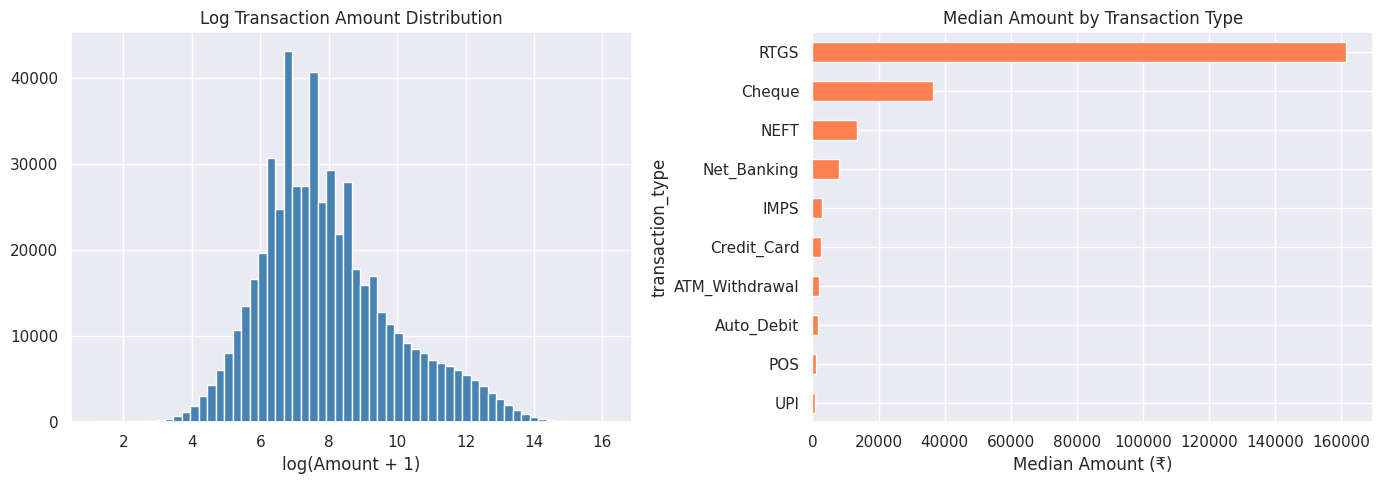

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(df['transaction_amount']), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Log Transaction Amount Distribution')
axes[0].set_xlabel('log(Amount + 1)')

df.groupby('transaction_type')['transaction_amount'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Median Amount by Transaction Type')
axes[1].set_xlabel('Median Amount (₹)')

plt.tight_layout()
plt.show()

## 3. Transaction Volume Trends

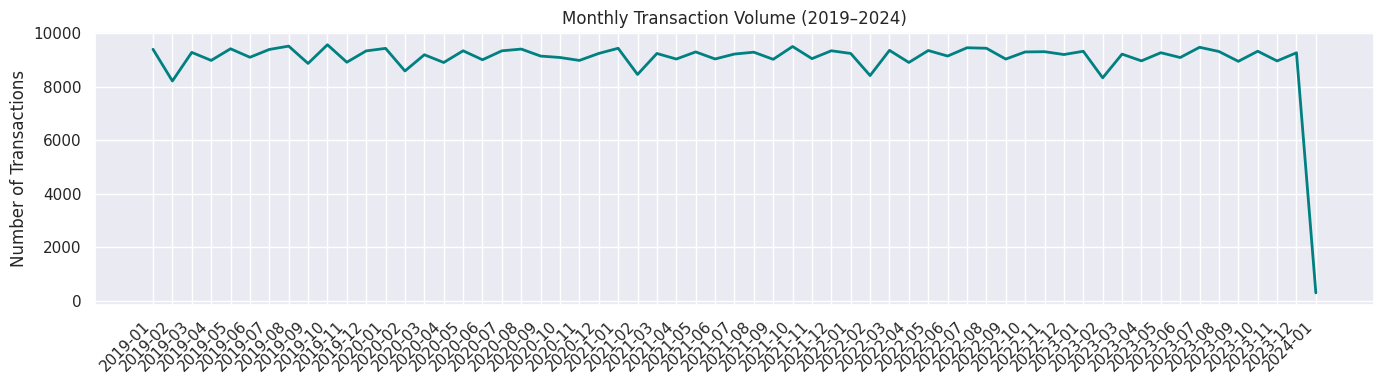

In [4]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly = df.groupby('year_month').size().reset_index(name='count')
monthly['year_month'] = monthly['year_month'].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(monthly['year_month'], monthly['count'], color='teal', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Transaction Volume (2019–2024)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

## 4. Fraud Analysis

Overall Fraud Rate: 0.886%
Fraud Transactions : 4,873
Legit Transactions : 545,127


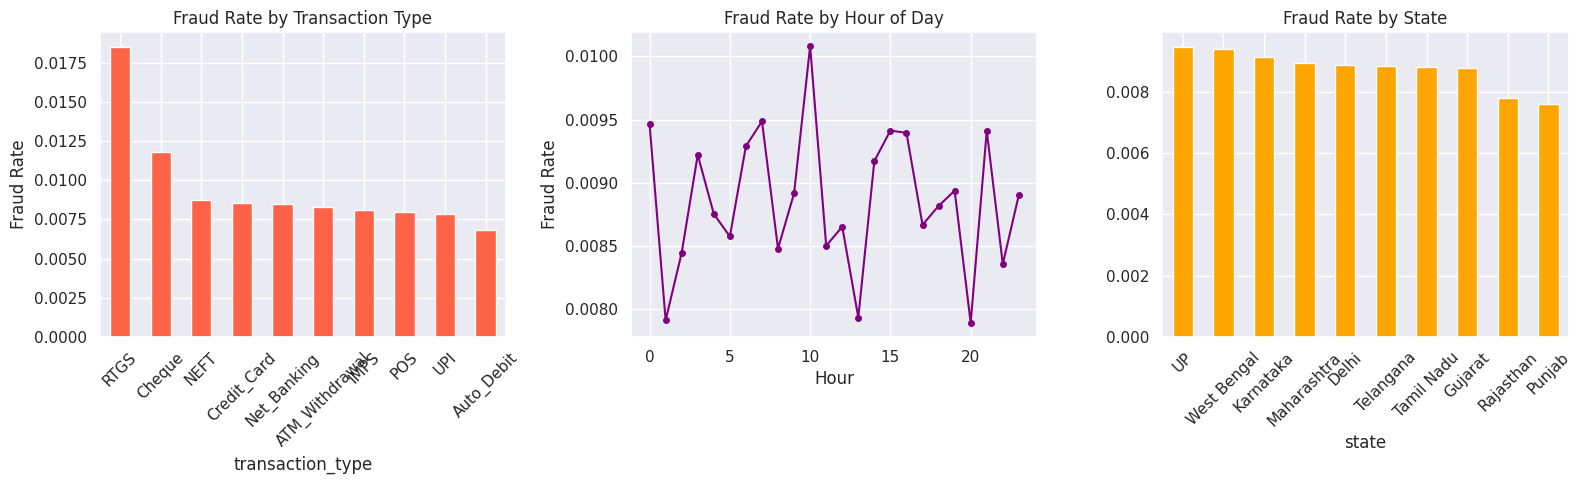

In [5]:
fraud_rate = df['is_fraud'].mean()
print(f'Overall Fraud Rate: {fraud_rate:.3%}')
print(f'Fraud Transactions : {df["is_fraud"].sum():,}')
print(f'Legit Transactions : {(df["is_fraud"]==0).sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fraud by transaction type
fraud_by_type = df.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Fraud Rate by Transaction Type')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)

# Fraud by hour
fraud_by_hour = df.groupby('transaction_hour')['is_fraud'].mean()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values, color='purple', marker='o', ms=4)
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')

# Fraud by state
fraud_by_state = df.groupby('state')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_state.plot(kind='bar', ax=axes[2], color='orange')
axes[2].set_title('Fraud Rate by State')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Channel & KYC Analysis

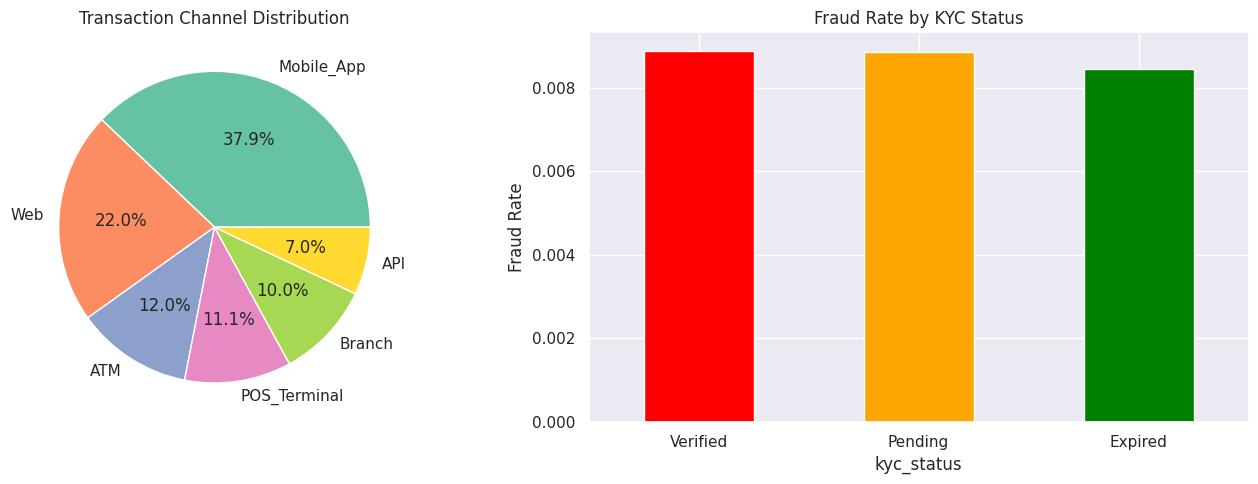

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_counts = df['channel'].value_counts()
axes[0].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(channel_counts)))
axes[0].set_title('Transaction Channel Distribution')

kyc_fraud = df.groupby('kyc_status')['is_fraud'].mean().sort_values(ascending=False)
kyc_fraud.plot(kind='bar', ax=axes[1], color=['red','orange','green'])
axes[1].set_title('Fraud Rate by KYC Status')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Baseline Fraud Detection Model

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

# Feature engineering
df_model = df.copy()
cat_cols = ['account_type','transaction_type','transaction_direction',
            'merchant_category','state','channel','kyc_status','loan_type']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

features = ['transaction_amount','account_balance','credit_score','transaction_hour',
            'has_loan','emi_amount','account_type','transaction_type',
            'transaction_direction','merchant_category','state','channel','kyc_status']

X = df_model[features]
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    109025
           1       0.00      0.00      0.00       975

    accuracy                           0.99    110000
   macro avg       0.50      0.50      0.50    110000
weighted avg       0.98      0.99      0.99    110000

ROC-AUC Score: 0.5292


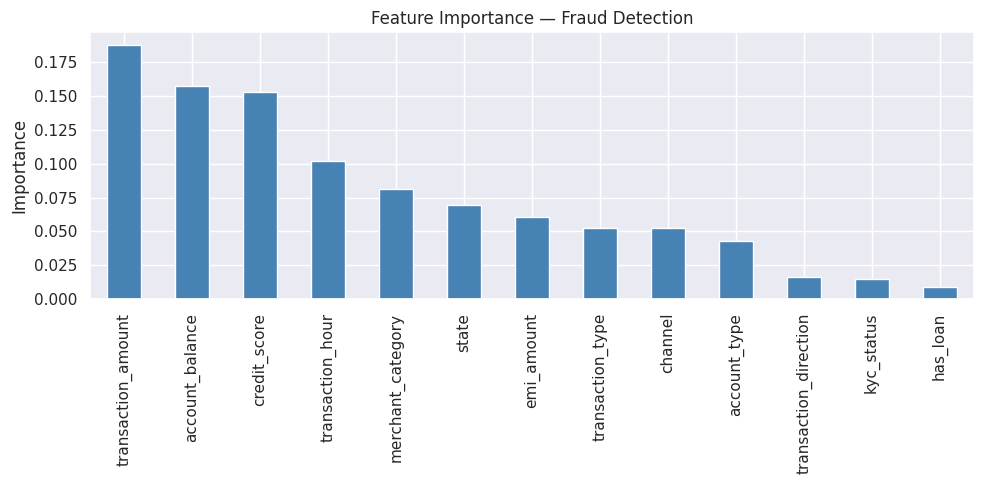

In [8]:
# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Fraud Detection')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

---
##  What's Next?
- Try **LightGBM / XGBoost** for better performance on imbalanced data
- Add **time-based features** (day of week, is_weekend, days_since_last_txn)
- Build **customer-level aggregations** (avg spend, txn frequency)
- Try **SMOTE / oversampling** to handle class imbalance
- Use **Isolation Forest** for unsupervised anomaly detection

> 💬 *If this notebook helped you, please upvote the dataset!*